In [ ]:
import numpy as np
import pandas as pd
import cv2
import PIL
import matplotlib.pyplot as plt
import random
import seaborn as sns

In [ ]:
# Load The data
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
!unzip '/content/drive/MyDrive/MIAS Mammography.zip'

Archive:  /content/drive/MyDrive/MIAS Mammography.zip
  inflating: Info.txt                
  inflating: all-mias.tar.gz         
  inflating: all-mias/Info.txt       
  inflating: all-mias/Licence.txt    
  inflating: all-mias/README         
  inflating: all-mias/mdb001.pgm     
  inflating: all-mias/mdb002.pgm     
  inflating: all-mias/mdb003.pgm     
  inflating: all-mias/mdb004.pgm     
  inflating: all-mias/mdb005.pgm     
  inflating: all-mias/mdb006.pgm     
  inflating: all-mias/mdb007.pgm     
  inflating: all-mias/mdb008.pgm     
  inflating: all-mias/mdb009.pgm     
  inflating: all-mias/mdb010.pgm     
  inflating: all-mias/mdb011.pgm     
  inflating: all-mias/mdb012.pgm     
  inflating: all-mias/mdb013.pgm     
  inflating: all-mias/mdb014.pgm     
  inflating: all-mias/mdb015.pgm     
  inflating: all-mias/mdb016.pgm     
  inflating: all-mias/mdb017.pgm     
  inflating: all-mias/mdb018.pgm     
  inflating: all-mias/mdb019.pgm     
  inflating: all-mias/mdb020.pgm  

In [ ]:
Data_info=pd.read_csv("/content/Info.txt",sep=" ")
Data_info=Data_info.drop('Unnamed: 7',axis=1)

In [ ]:
Data_info.head()

,REFNUM,BG,CLASS,SEVERITY,X,Y,RADIUS
0,mdb001,G,CIRC,B,535.0,425.0,197.0
1,mdb002,G,CIRC,B,522.0,280.0,69.0
2,mdb003,D,NORM,NaN,NaN,NaN,NaN
3,mdb004,D,NORM,NaN,NaN,NaN,NaN
4,mdb005,F,CIRC,B,477.0,133.0,30.0


In [ ]:
Data_info.reset_index(inplace = True)
Data_info

,index,REFNUM,BG,CLASS,SEVERITY,X,Y,RADIUS
0,0,mdb001,G,CIRC,B,535.0,425.0,197.0
1,1,mdb002,G,CIRC,B,522.0,280.0,69.0
2,2,mdb003,D,NORM,NaN,NaN,NaN,NaN
3,3,mdb004,D,NORM,NaN,NaN,NaN,NaN
4,4,mdb005,F,CIRC,B,477.0,133.0,30.0
...,...,...,...,...,...,...,...,...
325,325,mdb318,D,NORM,NaN,NaN,NaN,NaN
326,326,mdb319,D,NORM,NaN,NaN,NaN,NaN
327,327,mdb320,D,NORM,NaN,NaN,NaN,NaN
328,328,mdb321,D,NORM,NaN,NaN,NaN,NaN


In [ ]:
Data_info = Data_info.drop([3], axis=0)
Data_info.reset_index(inplace = True)
Data_info

,level_0,index,REFNUM,BG,CLASS,SEVERITY,X,Y,RADIUS
0,0,0,mdb001,G,CIRC,B,535.0,425.0,197.0
1,1,1,mdb002,G,CIRC,B,522.0,280.0,69.0
2,2,2,mdb003,D,NORM,NaN,NaN,NaN,NaN
3,4,4,mdb005,F,CIRC,B,477.0,133.0,30.0
4,5,5,mdb005,F,CIRC,B,500.0,168.0,26.0
...,...,...,...,...,...,...,...,...,...
324,325,325,mdb318,D,NORM,NaN,NaN,NaN,NaN
325,326,326,mdb319,D,NORM,NaN,NaN,NaN,NaN
326,327,327,mdb320,D,NORM,NaN,NaN,NaN,NaN
327,328,328,mdb321,D,NORM,NaN,NaN,NaN,NaN


In [ ]:
Data_info.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 329 entries, 0 to 328
Data columns (total 9 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   level_0   329 non-null    int64  
 1   index     329 non-null    int64  
 2   REFNUM    329 non-null    object 
 3   BG        329 non-null    object 
 4   CLASS     329 non-null    object 
 5   SEVERITY  123 non-null    object 
 6   X         119 non-null    float64
 7   Y         119 non-null    float64
 8   RADIUS    119 non-null    float64
dtypes: float64(3), int64(2), object(4)
memory usage: 23.3+ KB


In [ ]:
Data_info.describe()

,level_0,index,X,Y,RADIUS
count,329.000000,329.000000,119.000000,119.000000,119.000000
mean,164.990881,164.990881,488.605042,520.983193,48.848739
std,95.134067,95.134067,134.144131,178.828342,33.558863
min,0.000000,0.000000,127.000000,125.000000,3.000000
25%,83.000000,83.000000,398.500000,427.000000,27.000000
50%,165.000000,165.000000,505.000000,524.000000,41.000000
75%,247.000000,247.000000,574.500000,621.000000,61.500000
max,329.000000,329.000000,793.000000,994.000000,197.000000


In [ ]:
Data_info['CLASS'].unique()

array(['CIRC', 'NORM', 'MISC', 'ASYM', 'ARCH', 'SPIC', 'CALC'],
      dtype=object)

In [ ]:
Data_info['CLASS'].value_counts()

NORM    206
CALC     30
CIRC     25
ARCH     19
SPIC     19
MISC     15
ASYM     15
Name: CLASS, dtype: int64

In [ ]:
Total_number_of_images = len(Data_info['CLASS'])
Total_number_of_Healthy_images = 0
Total_number_of_Sick_images = 0
for i in range(len(Data_info)):
  if Data_info.CLASS[i]== 'NORM' :
    Total_number_of_Healthy_images = Total_number_of_Healthy_images+ 1
  else :
    Total_number_of_Sick_images  =Total_number_of_Sick_images + 1

In [ ]:
print('Total_number_of_images : ', Total_number_of_images)
print('Total_number_of_Healthy_images : ',Total_number_of_Healthy_images)
print('Total_number_of_Sick_images :  ',Total_number_of_Sick_images)

Total_number_of_images :  329
Total_number_of_Healthy_images :  206
Total_number_of_Sick_images :   123


In [ ]:
# taking the images filenames in to dictionary
dict_imges = {}
for i in range(len(Data_info)):
    dict_imges[i] = Data_info.REFNUM[i]

In [ ]:
# Turning our outputs Normal_healthy to 0-1
label = []
for i in range(len(Data_info)):
    if Data_info.CLASS[i] == 'NORM':
        label.append(0)
    else:
        label.append(1)

In [ ]:
label = np.array(label)

In [ ]:
imgs_path = '/content/all-mias'

In [ ]:
# define the every images filepaths in to list
img_name = []

for i in range(len(label)):
        img_name.append(imgs_path + '/'+Data_info.REFNUM[i]+ '.pgm')

In [ ]:
img_name = np.array(img_name)
img_name

array(['/content/all-mias/mdb001.pgm', '/content/all-mias/mdb002.pgm',
       '/content/all-mias/mdb003.pgm', '/content/all-mias/mdb005.pgm',
       '/content/all-mias/mdb005.pgm', '/content/all-mias/mdb006.pgm',
       '/content/all-mias/mdb007.pgm', '/content/all-mias/mdb008.pgm',
       '/content/all-mias/mdb009.pgm', '/content/all-mias/mdb010.pgm',
       '/content/all-mias/mdb011.pgm', '/content/all-mias/mdb012.pgm',
       '/content/all-mias/mdb013.pgm', '/content/all-mias/mdb014.pgm',
       '/content/all-mias/mdb015.pgm', '/content/all-mias/mdb016.pgm',
       '/content/all-mias/mdb017.pgm', '/content/all-mias/mdb018.pgm',
       '/content/all-mias/mdb019.pgm', '/content/all-mias/mdb020.pgm',
       '/content/all-mias/mdb021.pgm', '/content/all-mias/mdb022.pgm',
       '/content/all-mias/mdb023.pgm', '/content/all-mias/mdb024.pgm',
       '/content/all-mias/mdb025.pgm', '/content/all-mias/mdb026.pgm',
       '/content/all-mias/mdb027.pgm', '/content/all-mias/mdb028.pgm',
      

In [ ]:
#print(img_name)
print(f'image addres amount {img_name.shape}')

image addres amount (329,)


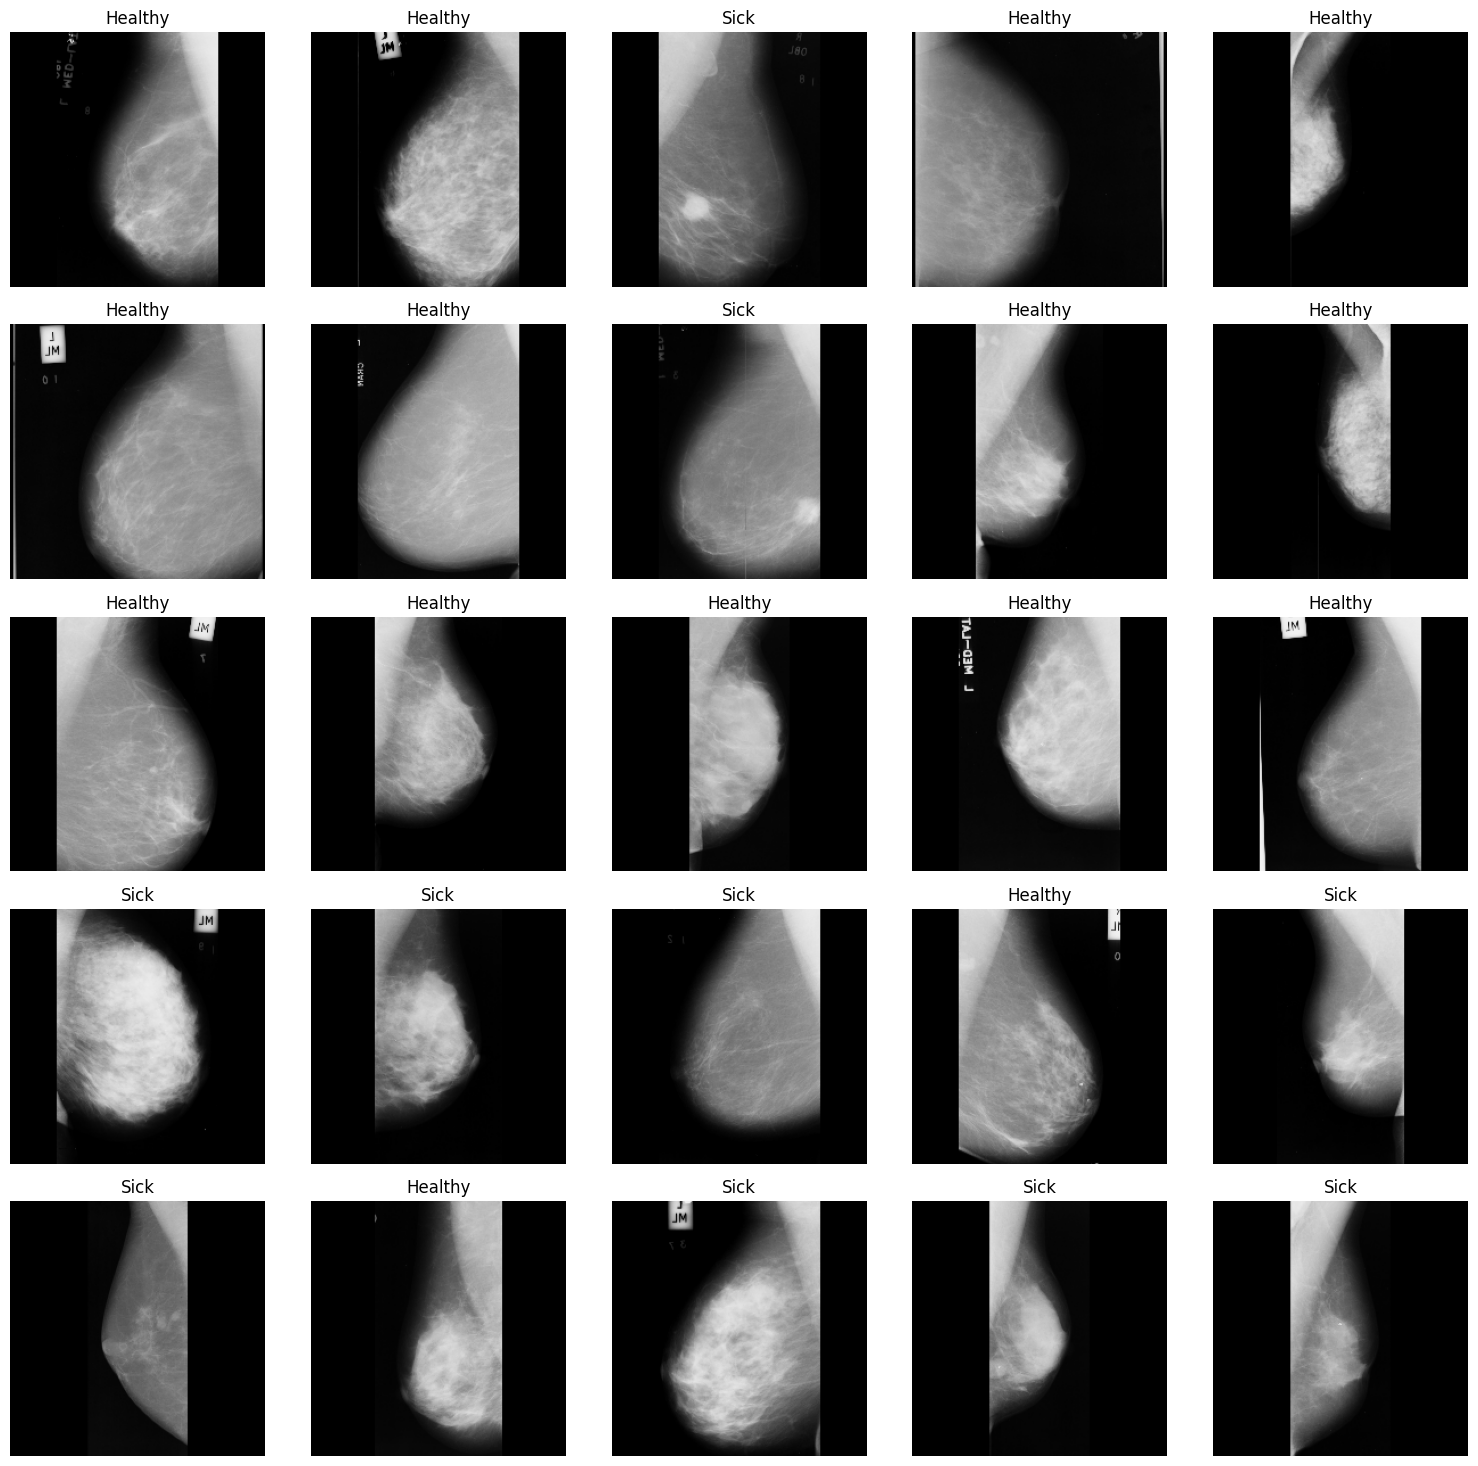

In [ ]:
# view image random images
def view_25_random_image():
    fig = plt.figure(figsize = (15, 15))
    for i in range(25):
        rand = random.randint(0,len(label))
        ax = plt.subplot(5, 5, i+1)

        img = cv2.imread(img_name[rand], 0)
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        img = cv2.resize(img, (224,224))
        if label[rand] == 0:
            plt.title('Healthy')
        else:
            plt.title('Sick')
        plt.tight_layout()
        plt.axis('off')
        plt.imshow(img.astype('uint8'))


random_images = view_25_random_image()


In [ ]:
from PIL import Image, ImageEnhance
img_healthy_arr= []
img_sick_arr=[]
for i in range(len(img_name)):

    img = cv2.imread(img_name[i], 0)
    img = cv2.resize(img, (128,128),cv2.COLOR_BGR2RGB)
    rows, cols= img.shape
    if label[i] == 0:
              img_healthy_arr.append([img,0])
    else:
              img_sick_arr.append([img,1])


In [ ]:
len(img_healthy_arr),len(img_sick_arr)

(206, 123)

In [ ]:
X = []
y = []

data_img_arr = np.concatenate((img_healthy_arr, img_sick_arr))
random.shuffle(data_img_arr)

for feature, label in data_img_arr:
    X.append(feature)
    y.append(label)

X = np.array(X)
y = np.array(y)



<__array_function__ internals>:180: VisibleDeprecationWarning: Creating an ndarray from ragged nested sequences (which is a list-or-tuple of lists-or-tuples-or ndarrays with different lengths or shapes) is deprecated. If you meant to do this, you must specify 'dtype=object' when creating the ndarray.


In [ ]:
from sklearn.model_selection import train_test_split
from keras.utils.np_utils import to_categorical
# Splitting the data to training and testing
X_train, X_test, y_train, y_test = train_test_split(X,y, test_size = 0.20, random_state = 42)
y_train = to_categorical(y_train, 2)
y_test = to_categorical(y_test, 2)

In [ ]:
len(X_train),len(X_test),len(y_train),len(y_test)

(263, 66, 263, 66)

In [ ]:
(a,b,c)=X_train.shape
X_train = np.reshape(X_train, (a, b, c, 1))
(a, b, c)=X_test.shape
X_test = np.reshape(X_test, (a, b, c, 1))

In [ ]:
print('X_train shape : {}' .format(X_train.shape))
print('X_test shape : {}' .format(X_test.shape))
print('y_train shape : {}' .format(y_train.shape))
print('y_test shape : {}' .format(y_test.shape))

X_train shape : (263, 128, 128, 1)
X_test shape : (66, 128, 128, 1)
y_train shape : (263, 2)
y_test shape : (66, 2)


In [ ]:
import tensorflow as tf

In [ ]:
model = tf.keras.Sequential([
tf.keras.layers.Conv2D(32, (3, 3), padding = 'same', activation = 'relu', input_shape = (128,128, 1)),
tf.keras.layers.MaxPooling2D(strides = 2),
tf.keras.layers.Conv2D(64, (3, 3), padding = 'same', activation = 'relu'),
tf.keras.layers.MaxPooling2D((3, 3),strides = 2),
tf.keras.layers.Conv2D(128, (3, 3), padding = 'same', activation = 'relu'),
tf.keras.layers.MaxPooling2D((3, 3),strides =2),
tf.keras.layers.Conv2D(128, (3, 3), padding = 'same', activation = 'relu'),
tf.keras.layers.MaxPooling2D((3, 3),strides =2),
tf.keras.layers.Flatten(),
tf.keras.layers.Dense(128, activation = 'relu'),
tf.keras.layers.Dense(2, activation = 'softmax')
])

In [ ]:
model.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d (Conv2D)             (None, 128, 128, 32)      320       
                                                                 
 max_pooling2d (MaxPooling2D  (None, 64, 64, 32)       0         
 )                                                               
                                                                 
 conv2d_1 (Conv2D)           (None, 64, 64, 64)        18496     
                                                                 
 max_pooling2d_1 (MaxPooling  (None, 31, 31, 64)       0         
 2D)                                                             
                                                                 
 conv2d_2 (Conv2D)           (None, 31, 31, 128)       73856     
                                                                 
 max_pooling2d_2 (MaxPooling  (None, 15, 15, 128)      0

In [ ]:
import tensorflow as tf

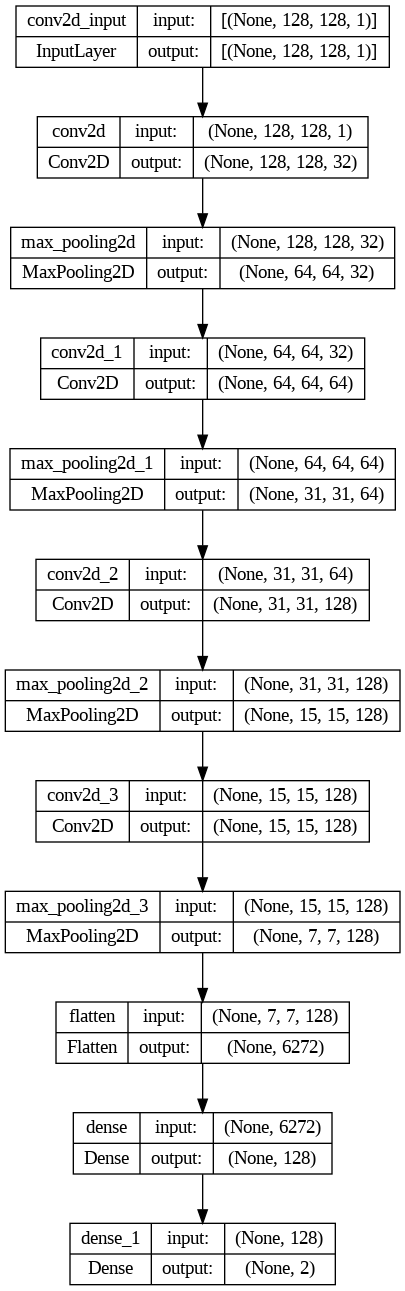

In [ ]:
tf.keras.utils.plot_model(model, "mammograhy_model.png", show_shapes=True)

In [ ]:
model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),loss='binary_crossentropy',metrics=['accuracy'])

In [ ]:
# trainig the model
history = model.fit(X_train, y_train, validation_data = (X_test, y_test), epochs = 25, batch_size = 32)

Epoch 1/25
10/10 [==============================] - 14s 71ms/step - loss: 2.7876 - accuracy: 0.8759 - val_loss: 0.6989 - val_accuracy: 0.8939
Epoch 2/25
10/10 [==============================] - 0s 18ms/step - loss: 0.2219 - accuracy: 0.9621 - val_loss: 0.3782 - val_accuracy: 0.8939
Epoch 3/25
10/10 [==============================] - 0s 18ms/step - loss: 0.1331 - accuracy: 0.9621 - val_loss: 0.3980 - val_accuracy: 0.8939
Epoch 4/25
10/10 [==============================] - 0s 19ms/step - loss: 0.1162 - accuracy: 0.9690 - val_loss: 0.7338 - val_accuracy: 0.8939
Epoch 5/25
10/10 [==============================] - 0s 19ms/step - loss: 0.1434 - accuracy: 0.9655 - val_loss: 0.2955 - val_accuracy: 0.9091
Epoch 6/25
10/10 [==============================] - 0s 18ms/step - loss: 0.1215 - accuracy: 0.9655 - val_loss: 0.4931 - val_accuracy: 0.8939
Epoch 7/25
10/10 [==============================] - 0s 20ms/step - loss: 0.0848 - accuracy: 0.9759 - val_loss: 0.3447 - val_accuracy: 0.9242
Epoch 8/25
1

In [ ]:
#Model evaluation
Loss, Accuracy = model.evaluate(X_test,y_test)

3/3 [==============================] - 0s 6ms/step - loss: 0.7606 - accuracy: 0.9394


In [ ]:
# Report of the result of Model
print('Loss of Model is :  ',Loss)
print('Accuracy of Model is :  ',Accuracy*100,'%')

Loss of Model is :   0.760628879070282
Accuracy of Model is :   93.9393937587738 %


3/3 [==============================] - 0s 4ms/step


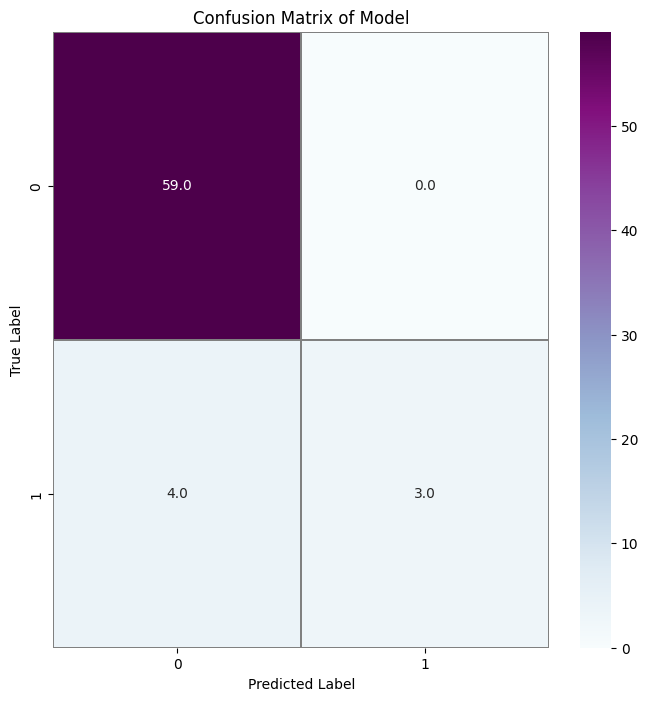

In [ ]:
from sklearn.metrics import confusion_matrix
Y_pred = model.predict(X_test)
Y_pred_classes = np.argmax(Y_pred,axis = 1)
Y_true = np.argmax(y_test,axis = 1)

confusion_mtx = confusion_matrix(Y_true, Y_pred_classes)
f,ax = plt.subplots(figsize=(8, 8))
sns.heatmap(confusion_mtx, annot=True, linewidths=0.01,cmap="BuPu",linecolor="gray", fmt= '.1f',ax=ax)
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix of Model")
plt.show()

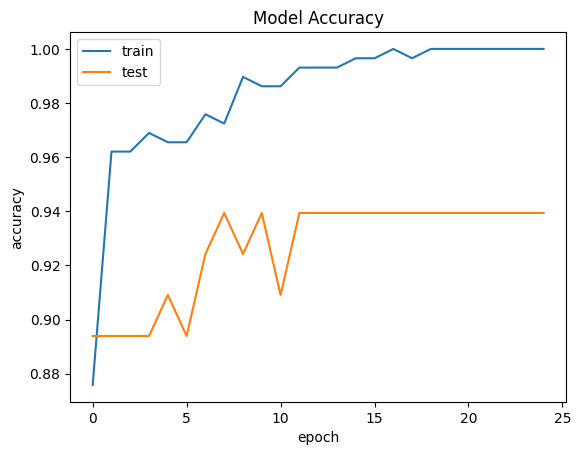

In [ ]:
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Model Accuracy')
plt.ylabel('accuracy')
plt.xlabel('epoch')
plt.legend(['train', 'test'], loc='upper left')
plt.show()

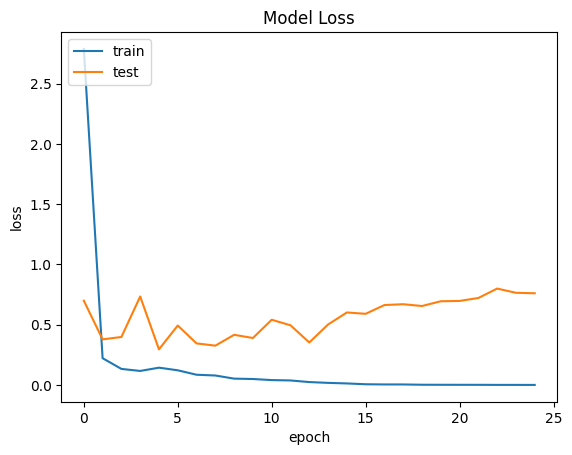

In [ ]:
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Model Loss')
plt.ylabel('loss')
plt.xlabel('epoch')
plt.legend(['train', 'test'], loc='upper left')
plt.show()

In [ ]:
# Make prediction
prediction = model.predict(X_test)
prediction

3/3 [==============================] - 0s 5ms/step


array([[1.0000000e+00, 9.8417904e-20],
       [9.9999976e-01, 2.5132616e-07],
       [1.0000000e+00, 7.9356292e-13],
       [1.0000000e+00, 9.8417904e-20],
       [1.0000000e+00, 1.0877532e-22],
       [1.0000000e+00, 1.4329564e-18],
       [1.0000000e+00, 5.6229261e-08],
       [1.0000000e+00, 6.9724699e-25],
       [9.9996281e-01, 3.7153877e-05],
       [1.0000000e+00, 4.7226035e-23],
       [1.0000000e+00, 2.0264105e-27],
       [1.0000000e+00, 5.3425821e-22],
       [1.0000000e+00, 1.6311794e-23],
       [1.0000000e+00, 2.2301267e-09],
       [1.0000000e+00, 5.5454703e-09],
       [1.0000000e+00, 1.6712268e-14],
       [1.0000000e+00, 6.0733299e-27],
       [1.0000000e+00, 8.8389482e-09],
       [1.0000000e+00, 9.8949147e-11],
       [1.0000000e+00, 2.2383423e-17],
       [1.0000000e+00, 3.8108393e-21],
       [1.0000000e+00, 1.4219399e-19],
       [9.9999988e-01, 8.7720579e-08],
       [9.9907100e-01, 9.2897686e-04],
       [1.0000000e+00, 8.7906109e-13],
       [9.9999976e-01, 2.

In [ ]:
from sklearn.metrics import accuracy_score,precision_score,recall_score, f1_score,classification_report, roc_auc_score, roc_curve, confusion_matrix, auc ,matthews_corrcoef
# Report of the results
prediction=np.argmax(prediction, axis=1)
y_test=np.argmax(y_test, axis=1)
print("Report of the result of mammography_data model : \n Confusion matrix : \n {} \n\nAccuracy Score:{}% \n\nPrecision Score:{}% \n\nRecall Score: {}% \n\nf1 score Score: {}%  \n\nmcc: {}%\n\nClassification Report : \n  {}".format(
      confusion_matrix(y_test,prediction),
      round(accuracy_score(y_test,prediction),3)*100 ,
      round(precision_score(y_test,prediction),3)*100,
      round(recall_score(y_test,prediction),3)*100,
      round(f1_score(y_test,prediction),3)*100,
      round(matthews_corrcoef(y_test,prediction),3)*100,
      classification_report(y_test,prediction)))

Report of the result of mammography_data model : 
 Confusion matrix : 
 [[59  0]
 [ 4  3]] 

Accuracy Score:93.89999999999999% 

Precision Score:100.0% 

Recall Score: 42.9% 

f1 score Score: 60.0%  

mcc: 63.4%

Classification Report : 
                precision    recall  f1-score   support

           0       0.94      1.00      0.97        59
           1       1.00      0.43      0.60         7

    accuracy                           0.94        66
   macro avg       0.97      0.71      0.78        66
weighted avg       0.94      0.94      0.93        66



In [ ]:
def img_plot(arr,index=0):
    plt.title('Test Image')
    plt.imshow(arr[index].astype('uint8'))

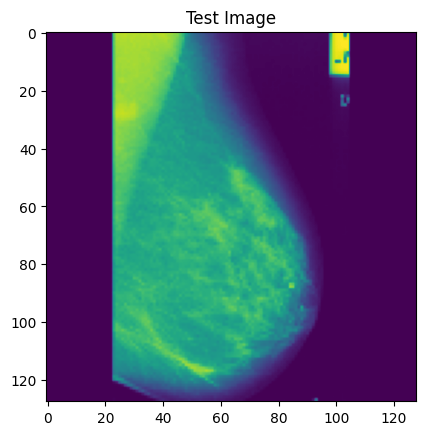

In [ ]:
index = 20
img_plot(X_test, index)

In [ ]:
input = X_test[index:index+1]

In [ ]:
pred =model.predict(input)[0].argmax()
label = y_test[index].argmax()

1/1 [==============================] - 0s 105ms/step


In [ ]:
print('Predicted Value using cnn model',pred)
print("True Value",label)

Predicted Value using cnn model 0
True Value 0
